### Plan para el futuro (próximo):
- Dividir Lung 1  en entrenamiento y test
- Random Survival forest solo con radiomicas
- Random Survival forest con caracteristicas clinicas
- Random survival forest combinado (clinicas + radiomicas)
- Progression Fre Survival (mismas 3 variantes)?

### Notas:
- No se ha podido hacer ICC sobre Manual delination. Se ha usado Wilcoxon sobre test/retest, pero parece que filtra demasiadas radiomicas. Probablemente habría que quitarlo.


### Carga de datos:


In [38]:
import numpy as np
import pandas as pd


In [40]:
df_radiomics = pd.read_csv('csv/radiomicas_combinadas_normalizado.csv')
df_radiomics["Patient"] = df_radiomics["Patient"].str.replace('"','',regex=False)



df_clinical = pd.read_csv('csv/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')


### Wilcoxon sobre Test/Retest

In [41]:
#No tenemos datos disponibles para hacer ICC en interobserver
#(datos no se corresponden con lo que debería)

#Nos quedamos solo con features cuyo p-value en Wilcoxon test-retest sea menor a 0.1
def filter_wilcoxon(file, treshold = 0.1):
    df = pd.read_csv(file, index_col=0)  # Use first column as index (feature names)
    p_values = df['pval']
    selected_features = p_values[p_values <= treshold].index.tolist()
    return selected_features

filtered_features = filter_wilcoxon('csv/mejores_radiomicas.csv')
print("Selected features based on Wilcoxon on test-retest data:", filtered_features)

Selected features based on Wilcoxon on test-retest data: ['original_gldm_DependenceNonUniformity', 'original_ngtdm_Busyness', 'original_shape_MinorAxisLength', 'wavelet-HHH_gldm_DependenceVariance', 'wavelet-HHH_glrlm_LongRunEmphasis', 'wavelet-HHH_glrlm_RunLengthNonUniformity', 'wavelet-HHH_ngtdm_Coarseness', 'wavelet-HHL_glcm_ClusterProminence', 'wavelet-HHL_gldm_DependenceEntropy', 'wavelet-HHL_glrlm_RunLengthNonUniformity', 'wavelet-HHL_glszm_GrayLevelVariance', 'wavelet-HHL_glszm_LargeAreaHighGrayLevelEmphasis', 'wavelet-HHL_ngtdm_Coarseness', 'wavelet-HHL_ngtdm_Contrast', 'wavelet-HLH_glszm_SizeZoneNonUniformity', 'wavelet-HLL_glszm_GrayLevelNonUniformity', 'wavelet-LHH_firstorder_Mean', 'wavelet-LHH_glcm_Imc2', 'wavelet-LHH_glcm_JointEnergy', 'wavelet-LHL_gldm_DependenceNonUniformity', 'wavelet-LLH_gldm_DependenceNonUniformity', 'wavelet-LLH_gldm_SmallDependenceEmphasis', 'wavelet-LLH_glrlm_RunLengthNonUniformityNormalized', 'wavelet-LLH_glrlm_RunPercentage', 'wavelet-LLH_glrlm_

### Wilcoxon - Correlación radiomicas - caracteristicas clinicas

In [42]:

from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# The Patient column in radiomics has format "LUNG1-XXX", and clinical PatientID also has "LUNG1-XXX"
# We can merge directly on Patient (from radiomics) and PatientID (from clinical)

# First, let's use the full Patient ID for merging
df_analysis = df_radiomics[['Patient'] + filtered_features].copy()
df_analysis = df_analysis.merge(df_clinical, left_on='Patient', right_on='PatientID', how='inner')

print(f"Analysis dataset shape: {df_analysis.shape}")
print(f"Number of features to test: {len(filtered_features)}")
print(f"Merged patients: {df_analysis.shape[0]}")

# Map actual clinical outcome column names
actual_clinical_outcomes = {
    'T_stage': 'clinical.T.Stage',
    'N_stage': 'Clinical.N.Stage',
    'M_stage': 'Clinical.M.Stage',
    'Overall_stage': 'Overall.Stage',
    'Histology': 'Histology',
    'Survival_time': 'Survival.time'
}

# Check which columns are present
present_outcomes = {k: v for k, v in actual_clinical_outcomes.items() if v in df_analysis.columns}
print(f"\nAvailable clinical outcomes: {present_outcomes}")

# Quick data overview
print("\nData types of outcomes:")
for outcome_name, col in present_outcomes.items():
    print(f"  {outcome_name} ({col}): {df_analysis[col].dtype}, unique values: {df_analysis[col].nunique()}")


Analysis dataset shape: (418, 41)
Number of features to test: 30
Merged patients: 418

Available clinical outcomes: {'T_stage': 'clinical.T.Stage', 'N_stage': 'Clinical.N.Stage', 'M_stage': 'Clinical.M.Stage', 'Overall_stage': 'Overall.Stage', 'Histology': 'Histology', 'Survival_time': 'Survival.time'}

Data types of outcomes:
  T_stage (clinical.T.Stage): float64, unique values: 5
  N_stage (Clinical.N.Stage): int64, unique values: 5
  M_stage (Clinical.M.Stage): int64, unique values: 3
  Overall_stage (Overall.Stage): str, unique values: 4
  Histology (Histology): str, unique values: 4
  Survival_time (Survival.time): int64, unique values: 373


"For the prediction models of survival outcomes, each continuous variable was transformed into a dichotomous set using the cutoff with the most significant survival difference determined by the “survMisc” package as a previous study reported"

In [43]:

# Function to find optimal cutoff for continuous survival data using log-rank test
def find_optimal_survival_cutoff(data, survival_col, event_col=None):
    """
    Find optimal cutoff for survival time that maximizes survival difference (Mann-Whitney U test)
    """
    survival_data = data[survival_col].dropna()
    
    if len(survival_data) < 10:
        # If too few samples, use median as cutoff
        cutoff = survival_data.median()
        print(f"Too few samples, using median as cutoff: {cutoff}")
        return cutoff
    
    # Test multiple potential cutoffs (percentiles)
    percentiles = np.arange(20, 80, 5)
    best_pval = 1.0
    best_cutoff = survival_data.median()
    
    for percentile in percentiles:
        cutoff = np.percentile(survival_data, percentile)
        group1 = survival_data[survival_data <= cutoff]
        group2 = survival_data[survival_data > cutoff]
        
        if len(group1) > 0 and len(group2) > 0:
            # Use Mann-Whitney U test as proxy for group differences
            stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
            
            if pval < best_pval:
                best_pval = pval
                best_cutoff = cutoff
    
    print(f"Optimal survival cutoff: {best_cutoff:.2f} (p-value: {best_pval:.4f})")
    return best_cutoff

# Find optimal cutoff for Survival.time
if 'Survival.time' in df_analysis.columns:
    survival_cutoff = find_optimal_survival_cutoff(df_analysis, 'Survival.time')
    df_analysis['Survival_binary'] = (df_analysis['Survival.time'] <= survival_cutoff).astype(int)
    print(f"Survival groups distribution: Low={sum(df_analysis['Survival_binary']==1)}, High={sum(df_analysis['Survival_binary']==0)}")
else:
    print("Warning: Survival.time column not found")


Optimal survival cutoff: 543.50 (p-value: 0.0000)
Survival groups distribution: Low=209, High=209


In [44]:

from scipy.stats import kruskal

# Function to run Wilcoxon test between features and clinical outcomes
def wilcoxon_test_features_vs_outcomes(df, features, outcomes_dict):
    """
    Run Mann-Whitney U test (Wilcoxon rank-sum) for each feature vs each outcome
    Returns results as DataFrame
    """
    results = []
    
    for outcome_name, outcome_col in outcomes_dict.items():
        # Special handling for Survival_binary
        if outcome_name == 'Survival_time' and outcome_col == 'Survival_binary':
            pass  # Use Survival_binary directly
        elif outcome_col not in df.columns:
            print(f"Warning: Column {outcome_col} not found, skipping {outcome_name}")
            continue
        
        # Get unique values/groups
        groups = df[outcome_col].dropna().unique()
        groups = groups[~pd.isna(groups)]
        
        print(f"\nTesting {outcome_name} ({outcome_col})")
        print(f"  Groups/categories: {sorted([str(g) for g in groups])}, N groups: {len(groups)}")
        
        for feature in features:
            if feature not in df.columns:
                continue
            
            feature_data = df[feature].dropna()
            outcome_data = df.loc[feature_data.index, outcome_col].dropna()
            feature_data = feature_data.loc[outcome_data.index]
            
            if len(feature_data) < 3:
                continue
            
            try:
                # For binary/categorical outcomes, compare feature values between groups
                if len(groups) == 2:
                    group1_mask = df[outcome_col] == groups[0]
                    group2_mask = df[outcome_col] == groups[1]
                    
                    group1_features = df.loc[group1_mask, feature].dropna()
                    group2_features = df.loc[group2_mask, feature].dropna()
                    
                    if len(group1_features) > 1 and len(group2_features) > 1:
                        stat, pval = mannwhitneyu(group1_features, group2_features, alternative='two-sided')
                        
                        results.append({
                            'Feature': feature,
                            'Clinical_Outcome': outcome_name,
                            'Outcome_Column': outcome_col,
                            'Groups': f"{groups[0]} vs {groups[1]}",
                            'Group1_N': len(group1_features),
                            'Group2_N': len(group2_features),
                            'Group1_Mean': group1_features.mean(),
                            'Group2_Mean': group2_features.mean(),
                            'U_Statistic': stat,
                            'P_Value': pval,
                            'Significant': 'Yes' if pval < 0.05 else 'No'
                        })
                else:
                    # For multi-class outcomes, use Kruskal-Wallis test
                    groups_data = [df.loc[df[outcome_col] == g, feature].dropna().values for g in groups]
                    groups_data = [g for g in groups_data if len(g) > 0]
                    
                    if len(groups_data) > 1:
                        stat, pval = kruskal(*groups_data)
                        
                        results.append({
                            'Feature': feature,
                            'Clinical_Outcome': outcome_name,
                            'Outcome_Column': outcome_col,
                            'Groups': f"Multi-class ({len(groups)} groups)",
                            'Group1_N': len(groups_data[0]),
                            'Group2_N': len(groups_data[1]) if len(groups_data) > 1 else 0,
                            'Group1_Mean': np.mean(groups_data[0]),
                            'Group2_Mean': np.mean(groups_data[1]) if len(groups_data) > 1 else np.nan,
                            'U_Statistic': stat,
                            'P_Value': pval,
                            'Significant': 'Yes' if pval < 0.05 else 'No'
                        })
            except Exception as e:
                print(f"  Error testing {feature} vs {outcome_name}: {str(e)}")
                continue
    
    return pd.DataFrame(results)

# Prepare outcomes dictionary (use binary version of Survival.time)
outcomes_to_test = {
    'T_Stage': 'clinical.T.Stage',
    'N_Stage': 'Clinical.N.Stage',
    'M_Stage': 'Clinical.M.Stage',
    'Overall_Stage': 'Overall.Stage',
    'Histology': 'Histology',
    'Survival_Time_Dichotomized': 'Survival_binary'
}

# Run Wilcoxon tests
print("=" * 80)
print("WILCOXON TEST: Filtered Features vs Clinical Outcomes")
print("=" * 80)

results_df = wilcoxon_test_features_vs_outcomes(df_analysis, filtered_features, outcomes_to_test)

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
print(f"Total tests performed: {len(results_df)}")
print(f"Significant tests (p < 0.05): {len(results_df[results_df['Significant'] == 'Yes'])}")
print("\nFirst 10 results:")
print(results_df.head(10))


WILCOXON TEST: Filtered Features vs Clinical Outcomes

Testing T_Stage (clinical.T.Stage)
  Groups/categories: ['1.0', '2.0', '3.0', '4.0', '5.0'], N groups: 5

Testing N_Stage (Clinical.N.Stage)
  Groups/categories: ['0', '1', '2', '3', '4'], N groups: 5

Testing M_Stage (Clinical.M.Stage)
  Groups/categories: ['0', '1', '3'], N groups: 3

Testing Overall_Stage (Overall.Stage)
  Groups/categories: ['I', 'II', 'IIIa', 'IIIb'], N groups: 4

Testing Histology (Histology)
  Groups/categories: ['adenocarcinoma', 'large cell', 'nos', 'squamous cell carcinoma'], N groups: 4

Testing Survival_Time_Dichotomized (Survival_binary)
  Groups/categories: ['0', '1'], N groups: 2

RESULTS SUMMARY
Total tests performed: 180
Significant tests (p < 0.05): 55

First 10 results:
                                    Feature Clinical_Outcome  \
0     original_gldm_DependenceNonUniformity          T_Stage   
1                   original_ngtdm_Busyness          T_Stage   
2            original_shape_MinorAxisL

In [45]:

# Detailed results with sorting and filtering
significant_results = results_df[results_df['Significant'] == 'Yes'].sort_values('P_Value')
non_significant_results = results_df[results_df['Significant'] == 'No'].sort_values('P_Value')

print("\n" + "=" * 80)
print("SIGNIFICANT CORRELATIONS (p < 0.05)")
print("=" * 80)
if len(significant_results) > 0:
    print(significant_results[['Feature', 'Clinical_Outcome', 'Groups', 'P_Value', 'Group1_Mean', 'Group2_Mean']].to_string(index=False))
    print(f"\nTotal significant: {len(significant_results)}")
else:
    print("No significant correlations found")

print("\n" + "=" * 80)
print("TOP 15 NON-SIGNIFICANT CORRELATIONS (lowest p-values)")
print("=" * 80)
if len(non_significant_results) > 0:
    print(non_significant_results[['Feature', 'Clinical_Outcome', 'Groups', 'P_Value', 'Group1_Mean', 'Group2_Mean']].head(15).to_string(index=False))

# Summary by clinical outcome
print("\n" + "=" * 80)
print("SUMMARY BY CLINICAL OUTCOME")
print("=" * 80)
for outcome in sorted(results_df['Clinical_Outcome'].unique()):
    outcome_results = results_df[results_df['Clinical_Outcome'] == outcome]
    sig_count = len(outcome_results[outcome_results['Significant'] == 'Yes'])
    total_count = len(outcome_results)
    print(f"\n{outcome}:")
    print(f"  Significant: {sig_count}/{total_count} ({100*sig_count/total_count:.1f}%)")
    if sig_count > 0:
        sig_features = outcome_results[outcome_results['Significant'] == 'Yes'].sort_values('P_Value')
        print(f"  Significant features (p < 0.05):")
        for idx, row in sig_features.iterrows():
            print(f"    - {row['Feature']}: p = {row['P_Value']:.6f}")

# Results saved to plots folder via visualizations



SIGNIFICANT CORRELATIONS (p < 0.05)
                                           Feature           Clinical_Outcome                 Groups  P_Value  Group1_Mean  Group2_Mean
                      wavelet-HHL_ngtdm_Coarseness                    T_Stage Multi-class (5 groups) 0.000006    -0.970259    -0.968077
                      wavelet-LLH_ngtdm_Coarseness                    T_Stage Multi-class (5 groups) 0.000008    -0.951258    -0.951753
          wavelet-HLL_glszm_GrayLevelNonUniformity                    T_Stage Multi-class (5 groups) 0.000019    -0.886977    -0.885660
                      wavelet-HHH_ngtdm_Coarseness                    T_Stage Multi-class (5 groups) 0.000037    -0.965475    -0.962315
                           original_ngtdm_Busyness                    T_Stage Multi-class (5 groups) 0.000038    -0.850897    -0.836776
          wavelet-HHH_glrlm_RunLengthNonUniformity                    T_Stage Multi-class (5 groups) 0.000039    -0.830202    -0.821835
          w

Visualization saved to: plots/wilcoxon_pvalues_by_outcome.png


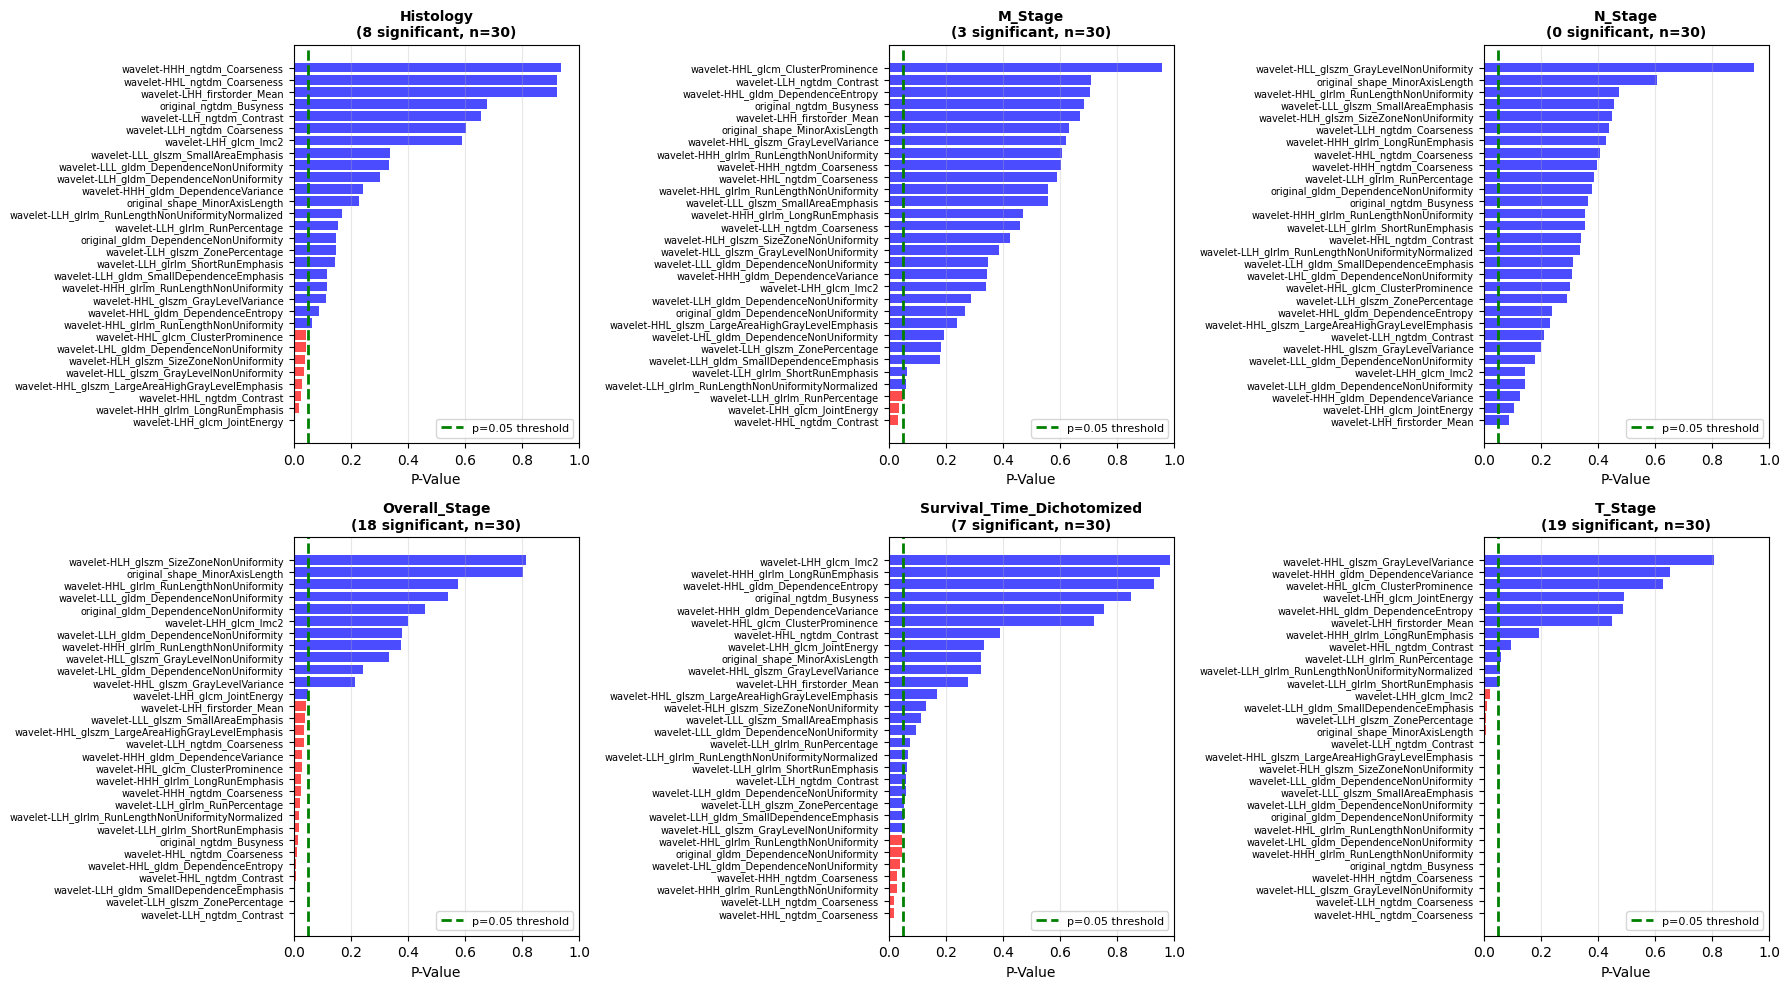

Heatmap saved to: plots/wilcoxon_heatmap.png
Heatmap saved to: wilcoxon_heatmap.png


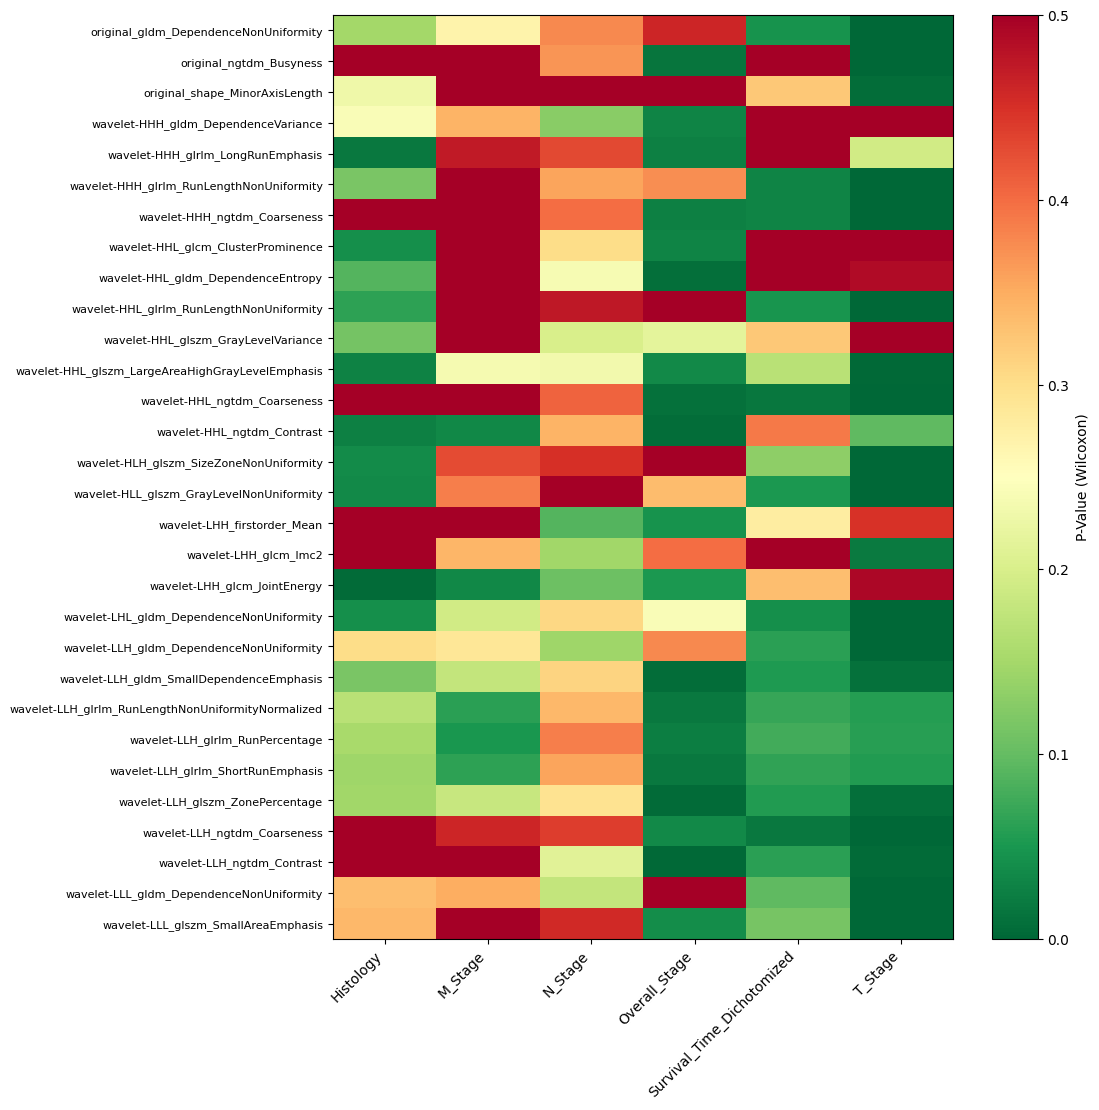

In [46]:

# Create visualization of p-values by clinical outcome
import matplotlib.pyplot as plt

# Calculate number of plots needed
n_outcomes = len(outcomes_to_test)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, outcome in enumerate(sorted(outcomes_to_test.keys())):
    outcome_data = results_df[results_df['Clinical_Outcome'] == outcome].copy()
    
    if len(outcome_data) == 0:
        axes[idx].text(0.5, 0.5, f'No data for {outcome}', ha='center', va='center')
        axes[idx].set_title(outcome)
        continue
    
    outcome_data = outcome_data.sort_values('P_Value')
    
    ax = axes[idx]
    colors = ['red' if p < 0.05 else 'blue' for p in outcome_data['P_Value']]
    
    ax.barh(range(len(outcome_data)), outcome_data['P_Value'], color=colors, alpha=0.7)
    ax.axvline(x=0.05, color='green', linestyle='--', linewidth=2, label='p=0.05 threshold')
    ax.set_yticks(range(len(outcome_data)))
    ax.set_yticklabels(outcome_data['Feature'], fontsize=7)
    ax.set_xlabel('P-Value')
    sig_count = len(outcome_data[outcome_data['P_Value'] < 0.05])
    ax.set_title(f'{outcome}\n({sig_count} significant, n={len(outcome_data)})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)

# Hide unused subplots
for idx in range(n_outcomes, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
import os
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/wilcoxon_pvalues_by_outcome.png', dpi=300, bbox_inches='tight')
print("Visualization saved to: plots/wilcoxon_pvalues_by_outcome.png")
plt.show()

# Create a heatmap-style visualization
fig, ax = plt.subplots(figsize=(10, 12))

# Pivot data for heatmap
pivot_data = results_df.pivot_table(values='P_Value', index='Feature', columns='Clinical_Outcome', aggfunc='min')

# Create heatmap
im = ax.imshow(pivot_data.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)

# Set ticks and labels
ax.set_xticks(range(len(pivot_data.columns)))
ax.set_yticks(range(len(pivot_data.index)))
ax.set_xticklabels(pivot_data.columns, rotation=45, ha='right')
ax.set_yticklabels(pivot_data.index, fontsize=8)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('P-Value (Wilcoxon)')

plt.savefig('plots/wilcoxon_heatmap.png', dpi=300, bbox_inches='tight')
print("Heatmap saved to: plots/wilcoxon_heatmap.png")
plt.savefig('wilcoxon_heatmap.png', dpi=300, bbox_inches='tight')
print("Heatmap saved to: wilcoxon_heatmap.png")

plt.show()


FEATURE RANKING: Overall Significance Across All Clinical Outcomes

Top 15 Most Significant Features (by minimum p-value across outcomes):
                                                  Min_P_Value  Mean_P_Value  Total_Tests  Significant_Count  Significance_Ratio
Feature                                                                                                                        
wavelet-HHL_ngtdm_Coarseness                         0.000006      0.324488            6                  3                50.0
wavelet-LLH_ngtdm_Coarseness                         0.000008      0.259602            6                  3                50.0
wavelet-HLL_glszm_GrayLevelNonUniformity             0.000019      0.292885            6                  2                33.3
wavelet-HHH_ngtdm_Coarseness                         0.000037      0.332750            6                  3                50.0
original_ngtdm_Busyness                              0.000038      0.432745            6    

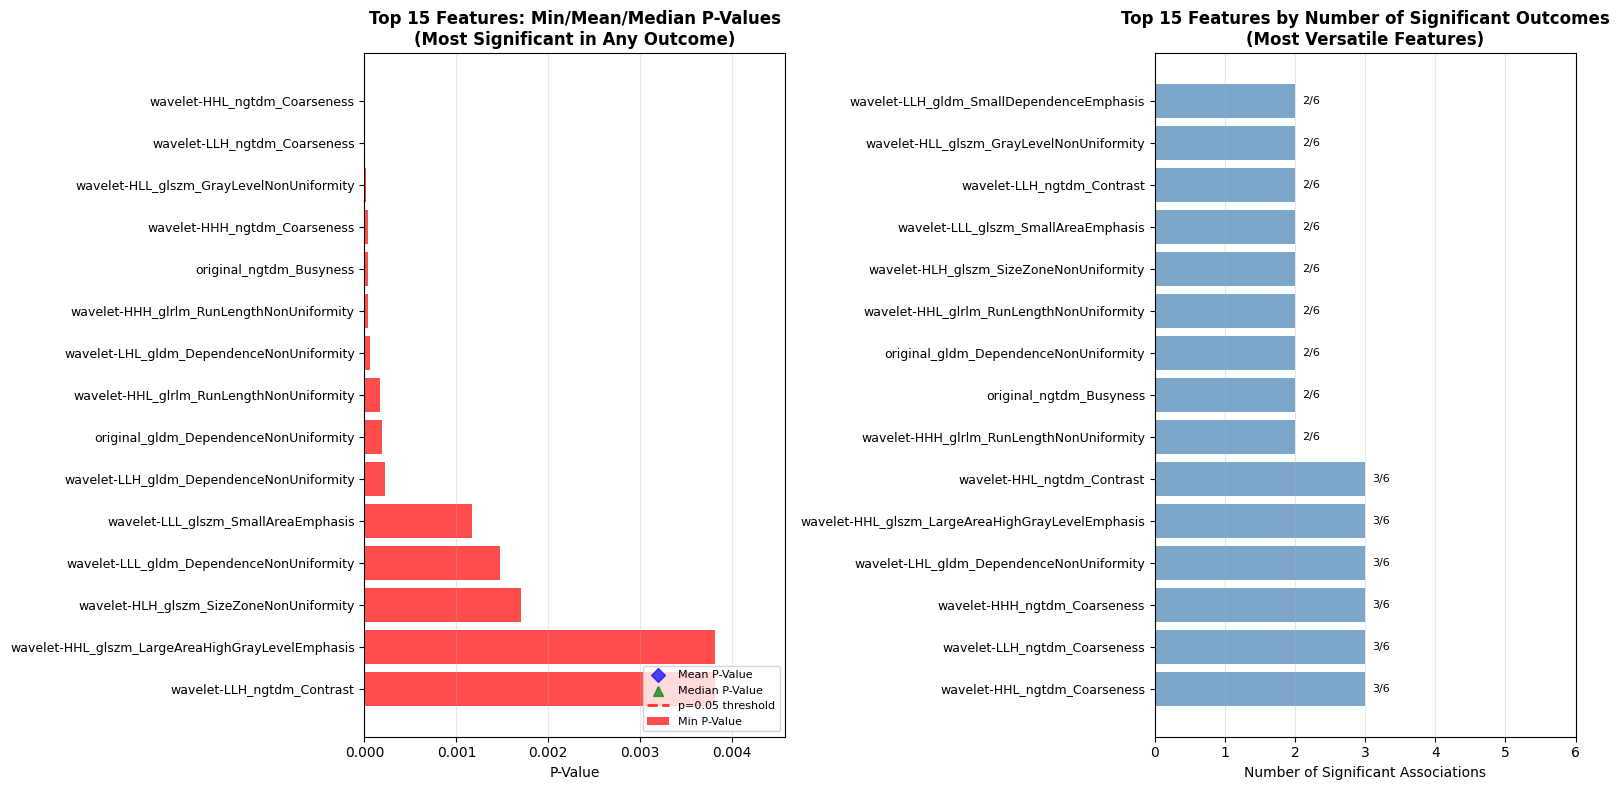

Feature ranking visualization saved to: plots/feature_ranking_top_features.png


<Figure size 640x480 with 0 Axes>


OVERALL SUMMARY STATISTICS
Total features tested: 30
Features with ≥1 significant association: 29
Features with ≥2 significant associations: 20
Features with ≥3 significant associations: 6

Average p-value across all tests: 0.268085
Median p-value across all tests: 0.179210


In [47]:

# Rank features by overall significance across all clinical outcomes
print("\n" + "=" * 80)
print("FEATURE RANKING: Overall Significance Across All Clinical Outcomes")
print("=" * 80)

# Aggregate statistics per feature
feature_stats = results_df.groupby('Feature').agg({
    'P_Value': ['min', 'mean', 'count'],  # min p-value, average p-value, number of tests
    'Significant': lambda x: (x == 'Yes').sum()  # count of significant associations
}).round(6)

feature_stats.columns = ['Min_P_Value', 'Mean_P_Value', 'Total_Tests', 'Significant_Count']
feature_stats['Significance_Ratio'] = (feature_stats['Significant_Count'] / feature_stats['Total_Tests'] * 100).round(1)
feature_stats = feature_stats.sort_values('Min_P_Value')

print("\nTop 15 Most Significant Features (by minimum p-value across outcomes):")
print(feature_stats.head(15).to_string())

# Ranking by different metrics
print("\n" + "-" * 80)
print("Top 10 Features by Number of Significant Associations:")
print("-" * 80)
top_by_count = feature_stats.sort_values('Significant_Count', ascending=False).head(10)
for idx, (feature, row) in enumerate(top_by_count.iterrows(), 1):
    print(f"{idx:2d}. {feature}")
    print(f"    Significant associations: {int(row['Significant_Count'])}/{int(row['Total_Tests'])}")
    print(f"    Best p-value: {row['Min_P_Value']:.6f}, Average p-value: {row['Mean_P_Value']:.6f}")

# Create comprehensive ranking table
print("\n" + "-" * 80)
print("Complete Feature Ranking Table:")
print("-" * 80)
ranking_df = feature_stats.copy()
ranking_df['Rank_by_MinP'] = range(1, len(ranking_df) + 1)
ranking_df = ranking_df.reset_index()
ranking_df = ranking_df[['Rank_by_MinP', 'Feature', 'Min_P_Value', 'Mean_P_Value', 
                          'Significant_Count', 'Total_Tests', 'Significance_Ratio']]
print(ranking_df.to_string(index=False))

# Rankings are displayed above

# Create visualization: Top features by significance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Top 15 features by minimum p-value
top15 = feature_stats.head(15).sort_values('Min_P_Value', ascending=False)
colors_min = ['red' if p < 0.05 else 'orange' for p in top15['Min_P_Value']]
ax1.barh(range(len(top15)), top15['Min_P_Value'], color=colors_min, alpha=0.7, label='Min P-Value')

# Add mean and median markers
ax1.scatter(top15['Mean_P_Value'], range(len(top15)), marker='D', color='blue', s=50, 
            alpha=0.7, label='Mean P-Value', zorder=3)

# Calculate median p-value for each feature
feature_medians = results_df.groupby('Feature')['P_Value'].median()
median_values = [feature_medians.get(feat, np.nan) for feat in top15.index]
ax1.scatter(median_values, range(len(top15)), marker='^', color='green', s=50, 
            alpha=0.7, label='Median P-Value', zorder=3)

ax1.axvline(x=0.05, color='red', linestyle='--', linewidth=2, alpha=0.8, label='p=0.05 threshold')
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15.index, fontsize=9)
ax1.set_xlabel('P-Value')
ax1.set_title('Top 15 Features: Min/Mean/Median P-Values\n(Most Significant in Any Outcome)', fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_xlim(0, max(top15['Min_P_Value']) * 1.2)
ax1.grid(axis='x', alpha=0.3)

# Right plot: Top 15 features by number of significant associations
top15_count = feature_stats.sort_values('Significant_Count', ascending=False).head(15)
bars = ax2.barh(range(len(top15_count)), top15_count['Significant_Count'], color='steelblue', alpha=0.7)
ax2.set_yticks(range(len(top15_count)))
ax2.set_yticklabels(top15_count.index, fontsize=9)
ax2.set_xlabel('Number of Significant Associations')
ax2.set_title('Top 15 Features by Number of Significant Outcomes\n(Most Versatile Features)', fontweight='bold')
ax2.set_xlim(0, 6)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(top15_count.iterrows()):
    ax2.text(row['Significant_Count'] + 0.1, i, f"{int(row['Significant_Count'])}/{int(row['Total_Tests'])}", 
             va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_ranking_top_features.png', dpi=300, bbox_inches='tight')
print("Feature ranking visualization saved to: feature_ranking_top_features.png")
plt.show()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/feature_ranking_top_features.png', dpi=300, bbox_inches='tight')
print("Feature ranking visualization saved to: plots/feature_ranking_top_features.png")
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("OVERALL SUMMARY STATISTICS")
print("=" * 80)
print(f"Total features tested: {len(feature_stats)}")
print(f"Features with ≥1 significant association: {(feature_stats['Significant_Count'] > 0).sum()}")
print(f"Features with ≥2 significant associations: {(feature_stats['Significant_Count'] >= 2).sum()}")
print(f"Features with ≥3 significant associations: {(feature_stats['Significant_Count'] >= 3).sum()}")
print(f"\nAverage p-value across all tests: {results_df['P_Value'].mean():.6f}")
print(f"Median p-value across all tests: {results_df['P_Value'].median():.6f}")


DETAILED P-VALUE STATISTICS FOR ALL FEATURES

All Features - Min/Median/Mean P-Values:
                                                       Min_P  Median_P    Mean_P     Max_P     Std_P  Significant_Count  Count
Feature                                                                                                                       
wavelet-HHL_ngtdm_Coarseness                        0.000006  0.211908  0.324488  0.924454  0.383296                  3      6
wavelet-LLH_ngtdm_Coarseness                        0.000008  0.237663  0.259602  0.604452  0.270859                  3      6
wavelet-HLL_glszm_GrayLevelNonUniformity            0.000019  0.193258  0.292885  0.947907  0.360188                  2      6
wavelet-HHH_ngtdm_Coarseness                        0.000037  0.214861  0.332750  0.938485  0.384745                  3      6
original_ngtdm_Busyness                             0.000038  0.522781  0.432745  0.849720  0.364459                  2      6
wavelet-HHH_glrlm_RunLe

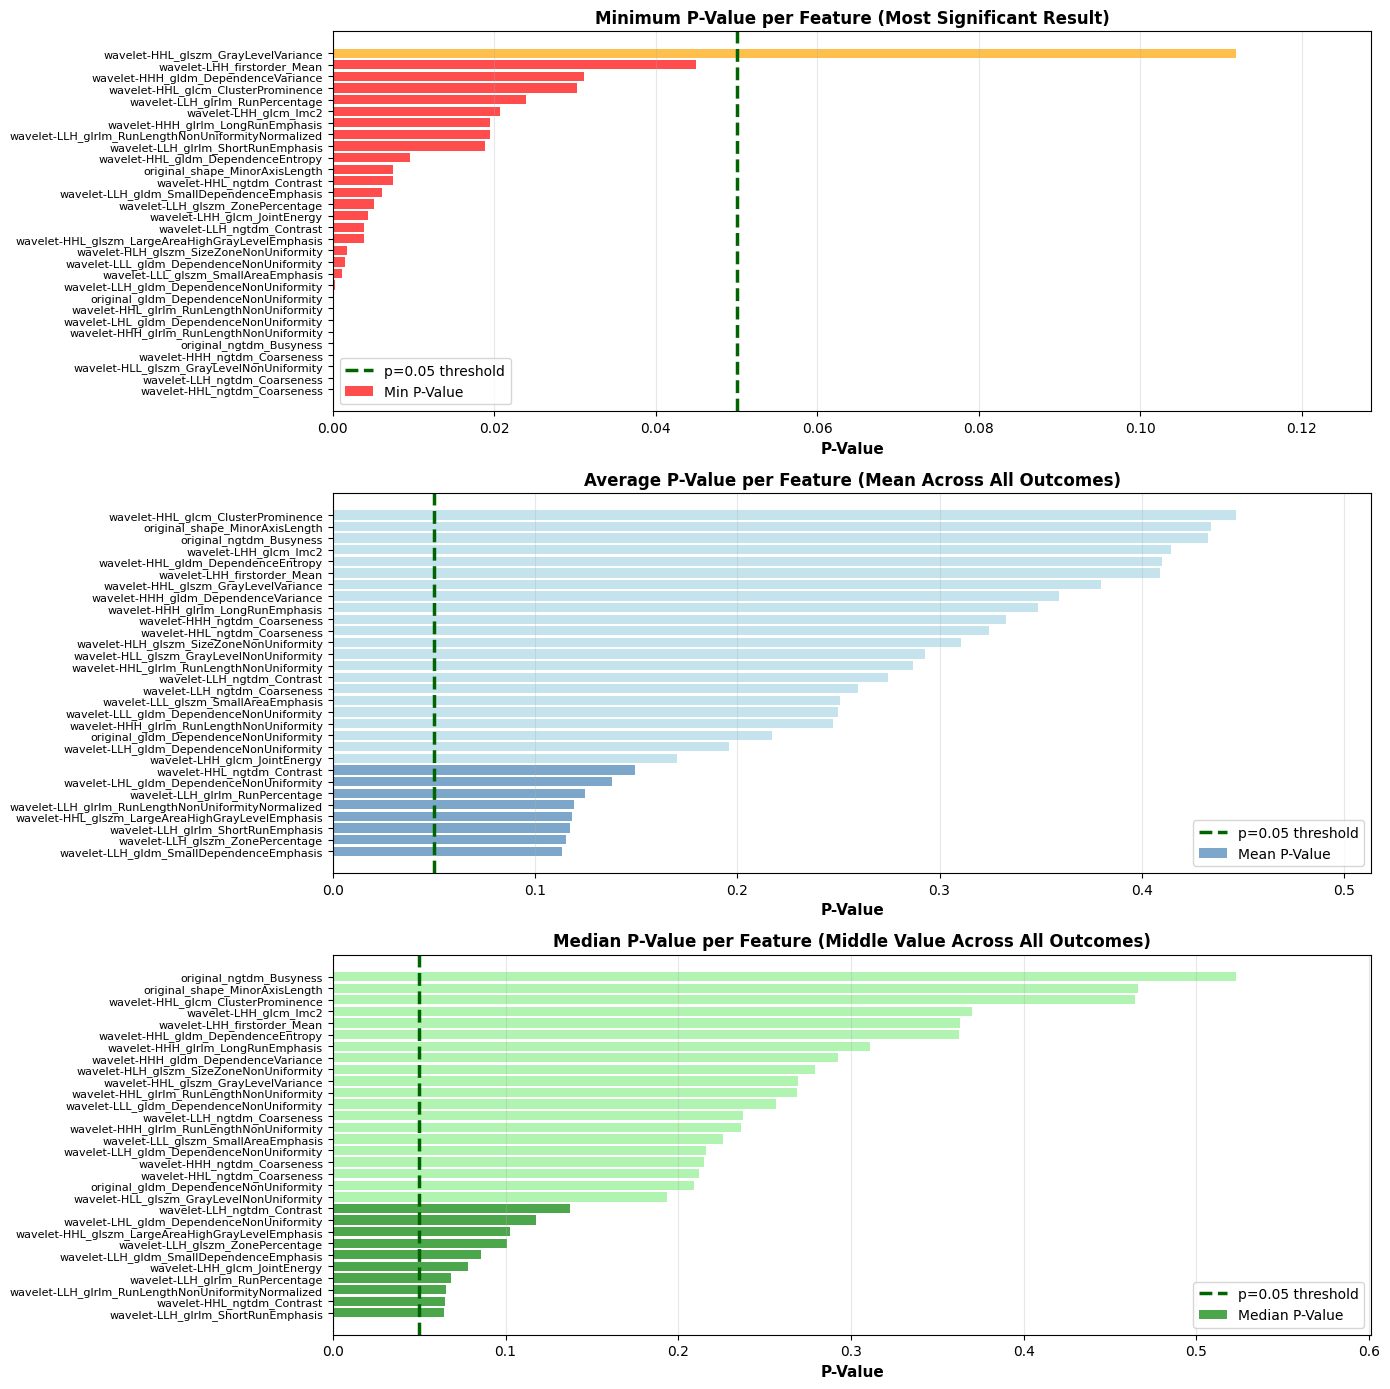

P-value comparison visualization saved to: plots/feature_pvalue_comparison.png


<Figure size 640x480 with 0 Axes>

P-value scatter comparison saved to: plots/feature_pvalue_scatter_comparison.png


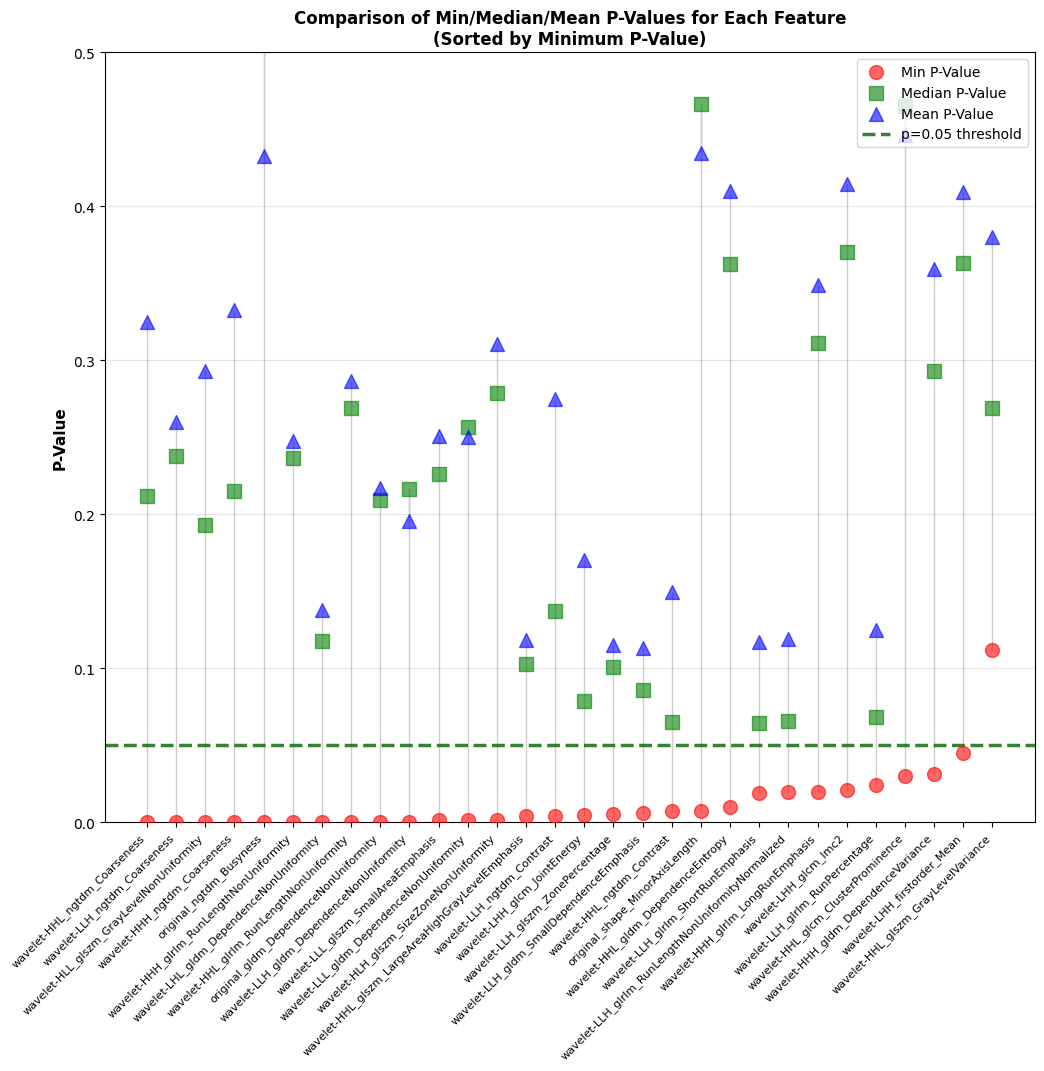


Summary: Min/Mean/Median P-Values
Average Minimum P-Value across features: 0.012443
Average Median P-Value across features: 0.228583
Average Mean P-Value across features: 0.268085

Features with Min P-Value < 0.001: 10
Features with Min P-Value < 0.01: 21
Features with Min P-Value < 0.05: 29

Features with Mean P-Value < 0.1: 0


In [49]:

# Detailed P-Value Statistics Table and Visualization
print("\n" + "=" * 100)
print("DETAILED P-VALUE STATISTICS FOR ALL FEATURES")
print("=" * 100)

# Create detailed statistics table
feature_pvalue_stats = results_df.groupby('Feature')['P_Value'].agg([
    ('Min_P', 'min'),
    ('Max_P', 'max'),
    ('Mean_P', 'mean'),
    ('Median_P', 'median'),
    ('Std_P', 'std'),
    ('Count', 'count')
]).round(6)

# Get significant count for each feature
sig_counts = results_df.groupby('Feature')['Significant'].apply(lambda x: (x == 'Yes').sum())
feature_pvalue_stats['Significant_Count'] = sig_counts

# Reorder columns and sort by Min_P
feature_pvalue_stats = feature_pvalue_stats[['Min_P', 'Median_P', 'Mean_P', 'Max_P', 'Std_P', 'Significant_Count', 'Count']]
feature_pvalue_stats = feature_pvalue_stats.sort_values('Min_P')

print("\nAll Features - Min/Median/Mean P-Values:")
print(feature_pvalue_stats.to_string())

# P-value statistics displayed above

# Create comprehensive visualization with all three metrics
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Minimum P-Value (sorted, all features)
top_features_by_min = feature_pvalue_stats.sort_values('Min_P')
ax = axes[0]
colors_min = ['red' if p < 0.05 else 'orange' for p in top_features_by_min['Min_P']]
bars1 = ax.barh(range(len(top_features_by_min)), top_features_by_min['Min_P'], color=colors_min, alpha=0.7, label='Min P-Value')
ax.axvline(x=0.05, color='darkgreen', linestyle='--', linewidth=2.5, label='p=0.05 threshold')
ax.set_yticks(range(len(top_features_by_min)))
ax.set_yticklabels(top_features_by_min.index, fontsize=8)
ax.set_xlabel('P-Value', fontsize=11, fontweight='bold')
ax.set_title('Minimum P-Value per Feature (Most Significant Result)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(top_features_by_min['Min_P']) * 1.15)

# Plot 2: Mean P-Value (sorted by mean)
top_features_by_mean = feature_pvalue_stats.sort_values('Mean_P')
ax = axes[1]
colors_mean = ['red' if p < 0.05 else 'steelblue' if p < 0.15 else 'lightblue' for p in top_features_by_mean['Mean_P']]
bars2 = ax.barh(range(len(top_features_by_mean)), top_features_by_mean['Mean_P'], color=colors_mean, alpha=0.7, label='Mean P-Value')
ax.axvline(x=0.05, color='darkgreen', linestyle='--', linewidth=2.5, label='p=0.05 threshold')
ax.set_yticks(range(len(top_features_by_mean)))
ax.set_yticklabels(top_features_by_mean.index, fontsize=8)
ax.set_xlabel('P-Value', fontsize=11, fontweight='bold')
ax.set_title('Average P-Value per Feature (Mean Across All Outcomes)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(top_features_by_mean['Mean_P']) * 1.15)

# Plot 3: Median P-Value (sorted by median)
top_features_by_median = feature_pvalue_stats.sort_values('Median_P')
ax = axes[2]
colors_median = ['red' if p < 0.05 else 'green' if p < 0.15 else 'lightgreen' for p in top_features_by_median['Median_P']]
bars3 = ax.barh(range(len(top_features_by_median)), top_features_by_median['Median_P'], color=colors_median, alpha=0.7, label='Median P-Value')
ax.axvline(x=0.05, color='darkgreen', linestyle='--', linewidth=2.5, label='p=0.05 threshold')
ax.set_yticks(range(len(top_features_by_median)))
ax.set_yticklabels(top_features_by_median.index, fontsize=8)
ax.set_xlabel('P-Value', fontsize=11, fontweight='bold')
ax.set_title('Median P-Value per Feature (Middle Value Across All Outcomes)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(top_features_by_median['Median_P']) * 1.15)

plt.tight_layout()
plt.savefig('feature_pvalue_comparison.png', dpi=300, bbox_inches='tight')
print("P-value comparison visualization saved to: feature_pvalue_comparison.png")
plt.show()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/feature_pvalue_comparison.png', dpi=300, bbox_inches='tight')
print("P-value comparison visualization saved to: plots/feature_pvalue_comparison.png")
plt.show()

# Create a scatter plot showing Min vs Mean vs Median
fig, ax = plt.subplots(figsize=(12, 10))

# Sort by Min_P for x-axis
sorted_features = feature_pvalue_stats.sort_values('Min_P')
x_pos = np.arange(len(sorted_features))

# Plot three scatter plots on same axis
ax.scatter(x_pos, sorted_features['Min_P'], s=100, marker='o', color='red', alpha=0.6, label='Min P-Value', zorder=3)
ax.scatter(x_pos, sorted_features['Median_P'], s=100, marker='s', color='green', alpha=0.6, label='Median P-Value', zorder=3)
ax.scatter(x_pos, sorted_features['Mean_P'], s=100, marker='^', color='blue', alpha=0.6, label='Mean P-Value', zorder=3)

# Add lines connecting points for each feature
for i in range(len(sorted_features)):
    min_p = sorted_features['Min_P'].iloc[i]
    med_p = sorted_features['Median_P'].iloc[i]
    mean_p = sorted_features['Mean_P'].iloc[i]
    ax.plot([i, i, i], [min_p, med_p, mean_p], 'k-', alpha=0.2, linewidth=1)

ax.axhline(y=0.05, color='darkgreen', linestyle='--', linewidth=2.5, alpha=0.8, label='p=0.05 threshold')
ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_features.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('P-Value', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(sorted_features['Max_P'].max() * 0.3, 0.5))
ax.set_title('Comparison of Min/Median/Mean P-Values for Each Feature\n(Sorted by Minimum P-Value)', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/feature_pvalue_scatter_comparison.png', dpi=300, bbox_inches='tight')
print("P-value scatter comparison saved to: plots/feature_pvalue_scatter_comparison.png")
plt.show()

print("\n" + "=" * 100)
print("Summary: Min/Mean/Median P-Values")
print("=" * 100)
print(f"Average Minimum P-Value across features: {feature_pvalue_stats['Min_P'].mean():.6f}")
print(f"Average Median P-Value across features: {feature_pvalue_stats['Median_P'].mean():.6f}")
print(f"Average Mean P-Value across features: {feature_pvalue_stats['Mean_P'].mean():.6f}")
print(f"\nFeatures with Min P-Value < 0.001: {(feature_pvalue_stats['Min_P'] < 0.001).sum()}")
print(f"Features with Min P-Value < 0.01: {(feature_pvalue_stats['Min_P'] < 0.01).sum()}")
print(f"Features with Min P-Value < 0.05: {(feature_pvalue_stats['Min_P'] < 0.05).sum()}")
print(f"\nFeatures with Mean P-Value < 0.1: {(feature_pvalue_stats['Mean_P'] < 0.1).sum()}")

In [56]:

# Feature Selection Functions: Survival Significance and Consistency
MEDIAN_THRESHOLD = 0.25
print("\n" + "=" * 100)
print("FEATURE SELECTION FUNCTIONS")
print("=" * 100)

def get_survival_significant_features(results_df, outcome_name='Survival_Time_Dichotomized', p_threshold=0.05):
    """
    Returns list of features significantly associated with survival binary outcome (p < threshold)
    
    Parameters:
    -----------
    results_df : DataFrame
        Results from wilcoxon_test_features_vs_outcomes containing Feature, Clinical_Outcome, P_Value columns
    outcome_name : str
        Name of the survival outcome to filter (default: 'Survival_Time_Dichotomized')
    p_threshold : float
        P-value threshold for significance (default: 0.05)
    
    Returns:
    --------
    list : Features significantly associated with survival outcomeMEDIAN_THRESHOLD)
    """
    survival_results = results_df[results_df['Clinical_Outcome'] == outcome_name]
    significant_features = survival_results[survival_results['P_Value'] < p_threshold]['Feature'].tolist()
    return sorted(significant_features)


def get_features_by_consistency(feature_pvalue_stats):
    """
    Returns features ordered by consistency across outcomes
    Consistency is measured by how close Min/Median/Mean p-values are to each other
    (Low spread = high consistency = "specialist" features good for multiple outcomes)
    
    Parameters:
    -----------
    feature_pvalue_stats : DataFrame
        Feature-level p-value statistics with columns Min_P, Median_P, Mean_P
    
    Returns:
    --------
    list : Feature names sorted by consistency (most consistent first)
    dict : Dictionary with consistency metrics for each feature
    """
    consistency_metrics = {}
    
    for feature in feature_pvalue_stats.index:
        min_p = feature_pvalue_stats.loc[feature, 'Min_P']
        median_p = feature_pvalue_stats.loc[feature, 'Median_P']
        mean_p = feature_pvalue_stats.loc[feature, 'Mean_P']
        
        # Calculate spread (standard deviation of the three metrics)
        # Lower spread = more consistent across outcomes
        spread = np.std([min_p, median_p, mean_p])
        
        # Calculate coefficient of variation (spread relative to magnitude)
        # Handles cases where p-values are very small
        avg_p = np.mean([min_p, median_p, mean_p])
        cv = spread / avg_p if avg_p > 0 else spread
        
        consistency_metrics[feature] = {
            'spread': spread,
            'coefficient_of_variation': cv,
            'range': feature_pvalue_stats.loc[feature, 'Max_P'] - feature_pvalue_stats.loc[feature, 'Min_P']
        }
    
    # Sort by spread (lower spread = more consistent)
    sorted_features = sorted(consistency_metrics.items(), key=lambda x: x[1]['spread'])
    sorted_feature_names = [feature for feature, metrics in sorted_features]
    
    return sorted_feature_names, consistency_metrics

def get_low_median_features(feature_pvalue_stats, threshold=MEDIAN_THRESHOLD):
    """
    Returns features with median p-value below a specified threshold
    These features are consistently significant across multiple outcomes
    
    Parameters:
    -----------
    feature_pvalue_stats : DataFrame
        Feature-level p-value statistics with column 'Median_P'
    threshold : float
        P-value threshold for median p-value (default: 0.1)
    
    Returns:
    --------
    list : Feature names with median p-value below threshold
    """
    low_median_features = feature_pvalue_stats[feature_pvalue_stats['Median_P'] < threshold].index.tolist()
    return sorted(low_median_features)


# Test the functions
print("\n1. FEATURES SIGNIFICANTLY ASSOCIATED WITH SURVIVAL (p < 0.05):")
print("-" * 100)
survival_features = get_survival_significant_features(results_df)
print(f"Found {len(survival_features)} features significant for Survival outcomes:")
for i, feature in enumerate(survival_features, 1):
    p_val = results_df[(results_df['Feature'] == feature) & 
                       (results_df['Clinical_Outcome'] == 'Survival_Time_Dichotomized')]['P_Value'].values[0]
    print(f"  {i}. {feature} (p = {p_val:.6f})")

print("\n2. FEATURES ORDERED BY CONSISTENCY ACROSS OUTCOMES:")
print("-" * 100)
print("(Low spread = high consistency = feature has similar significance across outcomes)")
consistent_features, consistency_data = get_features_by_consistency(feature_pvalue_stats)

print("\nTop 15 Most Consistent Features:")
for i, feature in enumerate(consistent_features[:15], 1):
    metrics = consistency_data[feature]
    min_p = feature_pvalue_stats.loc[feature, 'Min_P']
    median_p = feature_pvalue_stats.loc[feature, 'Median_P']
    mean_p = feature_pvalue_stats.loc[feature, 'Mean_P']
    print(f"\n  {i}. {feature}")
    print(f"     Min P: {min_p:.6f}, Median P: {median_p:.6f}, Mean P: {mean_p:.6f}")
    print(f"     Spread (Std Dev): {metrics['spread']:.6f}")
    print(f"     Coefficient of Variation: {metrics['coefficient_of_variation']:.4f}")

print("\n15 Least Consistent Features (Most Specialist):")
for i, feature in enumerate(consistent_features[-15:], 1):
    metrics = consistency_data[feature]
    min_p = feature_pvalue_stats.loc[feature, 'Min_P']
    median_p = feature_pvalue_stats.loc[feature, 'Median_P']
    mean_p = feature_pvalue_stats.loc[feature, 'Mean_P']
    print(f"\n  {i}. {feature}")
    print(f"     Min P: {min_p:.6f}, Median P: {median_p:.6f}, Mean P: {mean_p:.6f}")
    print(f"     Spread (Std Dev): {metrics['spread']:.6f}")
    print(f"     Coefficient of Variation: {metrics['coefficient_of_variation']:.4f}")

print(f"\n3. FEATURES WITH LOW MEDIAN P-VALUE (< {MEDIAN_THRESHOLD}):")
print("-" * 100)
low_median_features = get_low_median_features(feature_pvalue_stats)
print(f"Found {len(low_median_features)} features with median p-value < {MEDIAN_THRESHOLD}:")
for i, feature in enumerate(low_median_features, 1):
    median_p = feature_pvalue_stats.loc[feature, 'Median_P']
    print(f"  {i}. {feature} (Median P-Value: {median_p:.6f})")

# Summary comparison
print("\n" + "=" * 100)
print("SUMMARY COMPARISON")
print("=" * 100)
print(f"\nSurvival-significant features: {len(survival_features)}")
print(f"  {survival_features}")

print(f"\nMost consistent feature: {consistent_features[0]}")
print(f"  Spread: {consistency_data[consistent_features[0]]['spread']:.6f}")

print(f"\nLeast consistent (most specialist) feature: {consistent_features[-1]}")
print(f"  Spread: {consistency_data[consistent_features[-1]]['spread']:.6f}")

print(f"\n Features with low median p-value (< {MEDIAN_THRESHOLD}): {len(get_low_median_features(feature_pvalue_stats))}")



FEATURE SELECTION FUNCTIONS

1. FEATURES SIGNIFICANTLY ASSOCIATED WITH SURVIVAL (p < 0.05):
----------------------------------------------------------------------------------------------------
Found 7 features significant for Survival outcomes:
  1. original_gldm_DependenceNonUniformity (p = 0.045411)
  2. wavelet-HHH_glrlm_RunLengthNonUniformity (p = 0.029394)
  3. wavelet-HHH_ngtdm_Coarseness (p = 0.030809)
  4. wavelet-HHL_glrlm_RunLengthNonUniformity (p = 0.048554)
  5. wavelet-HHL_ngtdm_Coarseness (p = 0.017399)
  6. wavelet-LHL_gldm_DependenceNonUniformity (p = 0.041704)
  7. wavelet-LLH_ngtdm_Coarseness (p = 0.018378)

2. FEATURES ORDERED BY CONSISTENCY ACROSS OUTCOMES:
----------------------------------------------------------------------------------------------------
(Low spread = high consistency = feature has similar significance across outcomes)

Top 15 Most Consistent Features:

  1. wavelet-LLH_glrlm_ShortRunEmphasis
     Min P: 0.018808, Median P: 0.064308, Mean P: 0.11

### MDA SUM

In [60]:

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

def compute_mda_sum(estimator, X, y, cv, n_repeats=10, random_state=42):
    mda_by_fold = []
    all_importances = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = clone(estimator)
        model.fit(X_train, y_train)

        baseline_accuracy = accuracy_score(y_test, model.predict(X_test))
        perm = permutation_importance(
            model,
            X_test,
            y_test,
            scoring="accuracy",
            n_repeats=n_repeats,
            random_state=random_state + fold_idx,
            n_jobs=-1,
        )

        fold_result = pd.DataFrame({
            "feature": X.columns,
            "fold": fold_idx,
            "baseline_accuracy": baseline_accuracy,
            "mda_sum_fold": perm.importances.sum(axis=1),
            "mda_mean_fold": perm.importances_mean,
            "mda_std_fold": perm.importances_std,
        })

        mda_by_fold.append(fold_result)
        all_importances.append(perm.importances)

    mda_by_fold = pd.concat(mda_by_fold, ignore_index=True)
    all_importances = np.concatenate(all_importances, axis=1)

    ranking = (
        mda_by_fold.groupby("feature", as_index=False)
        .agg(
            mda_sum=("mda_sum_fold", "sum"),
            mda_mean=("mda_mean_fold", "mean"),
            mda_std=("mda_mean_fold", "std"),
        )
        .sort_values("mda_sum", ascending=False)
        .reset_index(drop=True)
    )

    ranking["times_more_important"] = ranking["mda_sum"] / ranking["mda_sum"].max()

    return ranking, mda_by_fold, all_importances


In [66]:
#survival_features
#low_median_features
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

features = low_median_features
tmp = df_radiomics[["Patient"] + list(features)].copy()
tmp = tmp.dropna(subset=features)

stage_map = df_clinical.set_index("PatientID")["Overall.Stage"]
tmp["Overall.Stage"] = tmp["Patient"].map(stage_map)
tmp = tmp.dropna(subset=["Overall.Stage"])

X = tmp[list(features)]
y = tmp["Overall.Stage"]

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stage_mda_ranking, mda_by_fold, raw_importances = compute_mda_sum(
    classifier, X, y, cv=cv, n_repeats=100, random_state=42
    )


print("Top features by MDA sum for Overall.Stage:")
display(stage_mda_ranking.head(20))

Top features by MDA sum for Overall.Stage:


,feature,mda_sum,mda_mean,mda_std,times_more_important
0,wavelet-LLH_gldm_SmallDependenceEmphasis,7.123064,0.014246,0.016500,1.000000
1,wavelet-HHH_glrlm_RunLengthNonUniformity,4.613741,0.009227,0.021213,0.647719
2,original_gldm_DependenceNonUniformity,3.831325,0.007663,0.015340,0.537876
3,wavelet-LLH_glszm_ZonePercentage,3.804073,0.007608,0.014891,0.534050
4,wavelet-LLL_glszm_SmallAreaEmphasis,3.531985,0.007064,0.034723,0.495852
5,wavelet-LLH_gldm_DependenceNonUniformity,2.055795,0.004112,0.019009,0.288611
6,wavelet-LLH_ngtdm_Contrast,0.240390,0.000481,0.028213,0.033748
7,wavelet-HHL_ngtdm_Coarseness,-1.988669,-0.003977,0.014003,-0.279187
8,wavelet-HLL_glszm_GrayLevelNonUniformity,-2.910069,-0.005820,0.015388,-0.408542
9,wavelet-LLH_ngtdm_Coarseness,-2.926563,-0.005853,0.025735,-0.410857


In [65]:
features = survival_features
tmp = df_radiomics[["Patient"] + list(features)].copy()
tmp = tmp.dropna(subset=features)

stage_map = df_clinical.set_index("PatientID")["deadstatus.event"]
tmp["deadstatus.event"] = tmp["Patient"].map(stage_map)
tmp = tmp.dropna(subset=["deadstatus.event"])

X = tmp[list(features)]
y = tmp["deadstatus.event"]

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stage_mda_ranking, mda_by_fold, raw_importances = compute_mda_sum(
    classifier, X, y, cv=cv, n_repeats=100, random_state=42
    )


print("Top features by MDA sum for deadstatus.event:")
display(stage_mda_ranking.head(20))

Top features by MDA sum for deadstatus.event:


,feature,mda_sum,mda_mean,mda_std,times_more_important
0,wavelet-HHL_glrlm_RunLengthNonUniformity,1.229633,0.002459,0.001572,1.000000
1,wavelet-LLH_ngtdm_Coarseness,0.684882,0.001370,0.007790,0.556981
2,wavelet-HHL_ngtdm_Coarseness,0.505450,0.001011,0.008399,0.411058
3,wavelet-LHL_gldm_DependenceNonUniformity,0.054647,0.000109,0.005652,0.044442
4,wavelet-HHH_glrlm_RunLengthNonUniformity,-0.118761,-0.000238,0.002482,-0.096582
5,wavelet-HHH_ngtdm_Coarseness,-0.486231,-0.000972,0.006169,-0.395428
6,original_gldm_DependenceNonUniformity,-0.946500,-0.001893,0.007293,-0.769742


### VIMP SUM

In [71]:
from sksurv.ensemble import RandomSurvivalForest 
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_censored
import numpy as np


def compute_vimp_sum_rsf_cv(X, y, cv_splits=5, n_estimators=100, random_state=42):
    """
    Compute Variable Importance (VIMP) sum for Random Survival Forest across CV folds.
    
    Uses permutation importance computed over each fold and sums across folds,
    similar to compute_mda_sum for Random Forest.
    
    Parameters:
    -----------
    X : DataFrame
        Feature matrix
    y : structured array
        Survival data with 'event' and 'time' fields  
    cv_splits : int
        Number of CV folds
    n_estimators : int
        Number of trees in forest
    random_state : int
        Random seed
        
    Returns:
    --------
    DataFrame : Feature importance ranking
    DataFrame : Per-fold importance values
    """
    
    vimp_by_fold = []
    all_importances = []
    feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f"Feature_{i}" for i in range(X.shape[1])]
    
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    X_vals = X.values if hasattr(X, 'values') else X

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_vals), start=1):
        X_train = X.iloc[train_idx] if hasattr(X, 'iloc') else X_vals[train_idx]
        X_test = X.iloc[test_idx] if hasattr(X, 'iloc') else X_vals[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        # Train model
        model = RandomSurvivalForest(n_estimators=n_estimators, random_state=random_state + fold_idx)
        X_train_vals = X_train.values if hasattr(X_train, 'values') else X_train
        X_test_vals = X_test.values if hasattr(X_test, 'values') else X_test
        model.fit(X_train_vals, y_train)

        # Baseline concordance index
        baseline_pred = model.predict(X_test_vals)
        baseline_c_index = concordance_index_censored(
            y_test['event'],
            y_test['time'],
            baseline_pred
        )[0]
        
        # Compute permutation importance manually
        importances_list = []
        
        for feature_idx, feature_name in enumerate(feature_names):
            # Create permuted copy using NumPy for consistency
            X_test_permuted = X_test_vals.copy()
            
            # Permute the feature column
            col_values = X_test_permuted[:, feature_idx].copy()
            rng = np.random.RandomState(random_state + fold_idx*100 + feature_idx)
            X_test_permuted[:, feature_idx] = rng.permutation(col_values)
            
            # Predict with permuted feature
            perm_pred = model.predict(X_test_permuted)
            perm_c_index = concordance_index_censored(
                y_test['event'],
                y_test['time'],
                perm_pred
            )[0]
            
            # Importance is decrease in concordance index (higher is better)
            importance = baseline_c_index - perm_c_index
            importances_list.append(importance)
        
        importances = np.array(importances_list)
        
        fold_result = pd.DataFrame({
            "feature": feature_names,
            "fold": fold_idx,
            "baseline_c_index": baseline_c_index,
            "vimp_fold": importances,
        })

        vimp_by_fold.append(fold_result)
        all_importances.append(importances)

    vimp_by_fold_df = pd.concat(vimp_by_fold, ignore_index=True)
    all_importances = np.array(all_importances).T  # Shape: (n_features, n_folds)

    # Aggregate across folds
    ranking = vimp_by_fold_df.groupby("feature", as_index=False).agg({
        "vimp_fold": ["sum", "mean", "std"],
        "baseline_c_index": "mean"
    }).reset_index(drop=True)
    
    # Flatten column names
    ranking.columns = ["feature", "vimp_sum", "vimp_mean", "vimp_std", "avg_c_index"]
    ranking = ranking.sort_values("vimp_sum", ascending=False).reset_index(drop=True)
    
    max_vimp = ranking["vimp_sum"].max()
    ranking["times_more_important"] = ranking["vimp_sum"] / max_vimp if max_vimp > 0 else 0

    return ranking, vimp_by_fold_df, all_importances


In [ ]:

# Prepare data
features = survival_features
tmp = df_radiomics[["Patient"] + list(features)].copy()
tmp = tmp.dropna(subset=features)

# Add survival data
survival_map = df_clinical.set_index("PatientID")["deadstatus.event"]
tmp["deadstatus.event"] = tmp["Patient"].map(survival_map)
time_map = df_clinical.set_index("PatientID")["Survival.time"]
tmp["Survival.time"] = tmp["Patient"].map(time_map)
tmp = tmp.dropna(subset=["deadstatus.event", "Survival.time"])

X = tmp[list(features)].copy()
event = tmp["deadstatus.event"].values.astype(bool)
time = tmp["Survival.time"].values

# Create structured array for survival data
y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

print(f"Preparing Random Survival Forest with {len(features)} features")
print(f"Sample size: {len(X)}")

print("\n" + "=" * 100)
print("COMPUTING VIMP SUM FOR RANDOM SURVIVAL FOREST")
print("=" * 100)

vimp_ranking, vimp_by_fold_df, all_vimp_values = compute_vimp_sum_rsf_cv(
    X, y, cv_splits=5, n_estimators=100, random_state=42
)

print(f"\nMean C-Index across folds: {vimp_by_fold_df['baseline_c_index'].mean():.4f}")
print(f"Std C-Index across folds: {vimp_by_fold_df['baseline_c_index'].std():.4f}")

print("\n" + "=" * 100)
print("Top 20 Features by VIMP Sum:")
print("=" * 100)
display(vimp_ranking.head(20))

print("\n" + "=" * 100)
print("Full VIMP Ranking:")
print("=" * 100)
print(vimp_ranking.to_string())

Preparing Random Survival Forest with 7 features
Sample size: 418

COMPUTING VIMP SUM FOR RANDOM SURVIVAL FOREST

Mean C-Index across folds: 0.5443
Std C-Index across folds: 0.0162

Top 20 Features by VIMP Sum:


,feature,vimp_sum,vimp_mean,vimp_std,avg_c_index,times_more_important
0,wavelet-LLH_ngtdm_Coarseness,0.155651,0.031130,0.015951,0.544272,1.000000
1,original_gldm_DependenceNonUniformity,0.092863,0.018573,0.032979,0.544272,0.596611
2,wavelet-HHL_ngtdm_Coarseness,0.068736,0.013747,0.020385,0.544272,0.441604
3,wavelet-HHL_glrlm_RunLengthNonUniformity,0.031200,0.006240,0.018619,0.544272,0.200450
4,wavelet-HHH_glrlm_RunLengthNonUniformity,-0.006764,-0.001353,0.013565,0.544272,-0.043454
5,wavelet-HHH_ngtdm_Coarseness,-0.010870,-0.002174,0.017202,0.544272,-0.069838
6,wavelet-LHL_gldm_DependenceNonUniformity,-0.019997,-0.003999,0.017200,0.544272,-0.128476



Full VIMP Ranking:
                                    feature  vimp_sum  vimp_mean  vimp_std  avg_c_index  times_more_important
0              wavelet-LLH_ngtdm_Coarseness  0.155651   0.031130  0.015951     0.544272              1.000000
1     original_gldm_DependenceNonUniformity  0.092863   0.018573  0.032979     0.544272              0.596611
2              wavelet-HHL_ngtdm_Coarseness  0.068736   0.013747  0.020385     0.544272              0.441604
3  wavelet-HHL_glrlm_RunLengthNonUniformity  0.031200   0.006240  0.018619     0.544272              0.200450
4  wavelet-HHH_glrlm_RunLengthNonUniformity -0.006764  -0.001353  0.013565     0.544272             -0.043454
5              wavelet-HHH_ngtdm_Coarseness -0.010870  -0.002174  0.017202     0.544272             -0.069838
6  wavelet-LHL_gldm_DependenceNonUniformity -0.019997  -0.003999  0.017200     0.544272             -0.128476
